# Exploratory Multivariate Analysis of Climatic, Sports and Socio-Economic Data : PCA, CA & MCA

**Authored by Alexandre Mathias DONNAT, Sr - Télécom Paris**

## Introduction

This notebook presents three applied case studies illustrating the use of factorial methods for exploratory multivariate data analysis.

- Case Study 1 applies Principal Component Analysis (PCA) to monthly temperature data for European cities in order to identify major climatic patterns and build a typology based on average temperature levels and seasonal variability.

- Case Study 2 uses Correspondence Analysis (CA) on an Olympic medal contingency table to explore the relationships between disciplines and countries and to identify dominant sporting specializations.

- Case Study 3 relies on Multiple Correspondence Analysis (MCA) to analyze categorical socio-economic data from a banking survey and to uncover underlying client profiles.

Across these examples, the notebook emphasizes geometric interpretation, inertia decomposition, and contributions, highlighting how factorial methods provide concise and interpretable representations of complex datasets.

In [81]:
# Our modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from scipy.stats import chi2_contingency
import mca


### Exercise 1

The dataset contains average monthly temperatures for different cities. Annual means and annual temperature ranges are also provided, along with geographic coordinates (latitude and longitude). A qualitative variable indicates the geographic area (north, south, east, or west).
The objective is to build a typology of cities using only the monthly temperature variables, and then to validate the analysis using the additional variables.

In [2]:
temperature = pd.read_csv("temperature.csv", sep=";")

#### Data description
We will first inspect the main characteristics of the dataset.

In [3]:
temperature = temperature.rename(columns={"Unnamed: 0": "City"})
temperature = temperature.set_index("City")

In [4]:
print(temperature.head(4))
print(temperature.shape)
print(temperature.columns[1:])
print(temperature.iloc[:,0].to_string(index=False))

            January  February  March  April   May  June  July  August  \
City                                                                    
Amsterdam       2.9       2.5    5.7    8.2  12.5  14.8  17.1    17.1   
Athens          9.1       9.7   11.7   15.4  20.1  24.5  27.4    27.2   
Berlin         -0.2       0.1    4.4    8.2  13.8  16.0  18.3    18.0   
Brussels        3.3       3.3    6.7    8.9  12.8  15.6  17.8    17.8   

            September  October  November  December  Annual  Amplitude  \
City                                                                    
Amsterdam        14.5     11.4       7.0       4.4     9.9       14.6   
Athens           23.8     19.2      14.6      11.0    17.8       18.3   
Berlin           14.4     10.0       4.2       1.2     9.1       18.5   
Brussels         15.0     11.1       6.7       4.4    10.3       14.4   

            Latitude  Longitude   Area  
City                                    
Amsterdam       52.2        4.5   West  

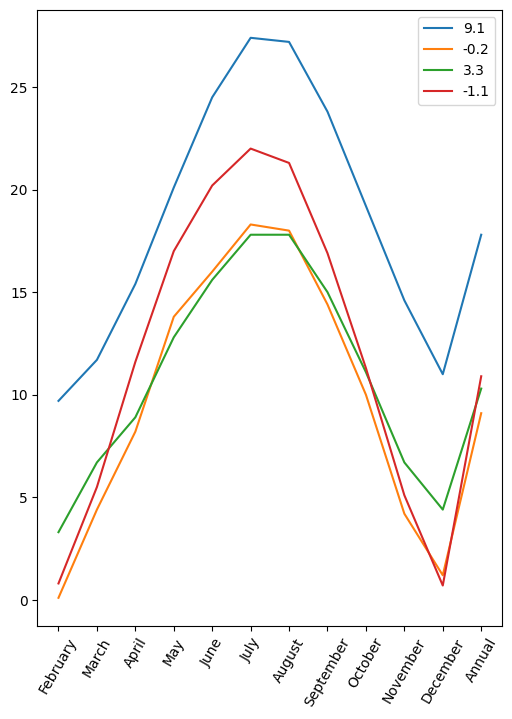

In [83]:
# Plot temperatures for the first 4 cities 
ax = temperature.iloc[1:5,1:13].T.plot()
ax.set_xticks(np.arange(12))
ax.set_xticklabels(temperature.columns[1:13])
ax.tick_params(axis='x', labelrotation = 60)
handles, _ = ax.get_legend_handles_labels()
ax.legend(handles, temperature.iloc[1:5,0])

### PCA of the dataset

We perform a PCA on the dataset. Individuals 24 to 35 are treated as supplementary individuals (they are not capital cities). We only use the monthly average temperature variables as active variables; the other variables are excluded from the PCA and kept as supplementary variables.

In [6]:
months = ["January","February","March","April","May","June","July","August",
          "September","October","November","December"]

t_capital = temperature.iloc[:24][months]        
t_sup     = temperature.iloc[24:35][months]        

scaler = StandardScaler()
t_capital_norm = scaler.fit_transform(t_capital)

# Create the PCA object and fit it to the active data
pca = PCA()
temp_pca = pca.fit_transform(t_capital_norm)

We plot the individuals’ scatter plot.

In [7]:
# Scores PCA
temp_pca = pca.transform(t_capital_norm)

pca_df = pd.DataFrame(
    temp_pca[:, :2],
    columns=["Dim1", "Dim2"],
    index=t_capital.index
).reset_index().rename(columns={"index": "City"})

pca_df["Area"] = temperature.loc[t_capital.index, "Area"].values

pca_df.head()

,City,Dim1,Dim2,Area
0,Amsterdam,0.205611,-1.347904,West
1,Athens,7.715648,1.019346,South
2,Berlin,-0.317512,0.063415,West
3,Brussels,0.617237,-1.148004,West
4,Budapest,1.675835,1.795421,East


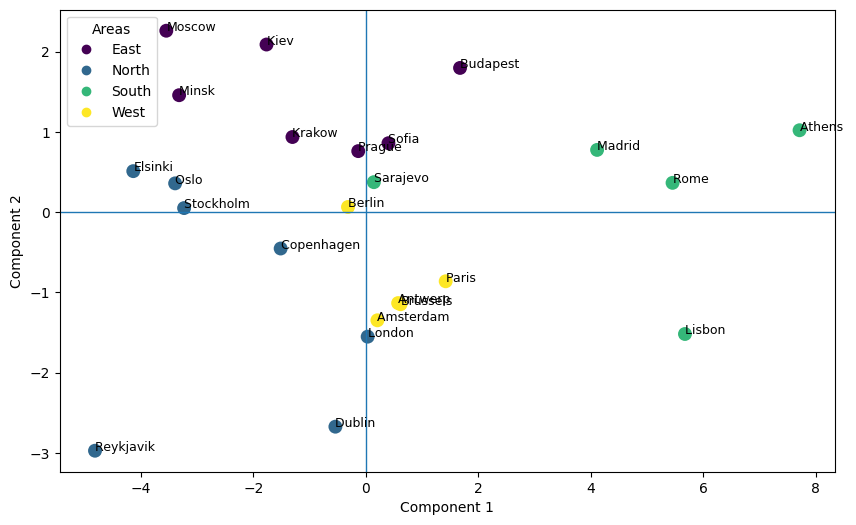

In [8]:
plt.rcParams['figure.figsize'] = (10, 6)
fig, ax = plt.subplots()

# sorted labels
area = sorted(pca_df["Area"].unique())

# color codes ALIGNED on pca_df (same length as Dim1/Dim2)
color_codes = pca_df["Area"].astype("category").cat.codes

scatter = ax.scatter(
    pca_df["Dim1"], pca_df["Dim2"],
    c=color_codes,
    edgecolor="none",
    s=100
)

for _, row in pca_df.iterrows():
    ax.annotate(row["City"], (row["Dim1"], row["Dim2"]), fontsize=9)

ax.legend(handles=scatter.legend_elements()[0], labels=area, title="Areas")
ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)
plt.show()

**Question 1**: How can the first two axes be interpreted in light of the results?

*Axis 1 (Component 1)*
The first axis corresponds to an overall thermal gradient. It contrasts cities with high temperatures throughout the year (located on the right side of the axis, mainly in Southern Europe such as Athens, Madrid, or Rome) with colder cities (located on the left, especially in Northern Europe such as Reykjavik, Helsinki, or Oslo). This axis can therefore be interpreted as a North–South axis, strongly related to the average temperature level.

*Axis 2 (Component 2)*
The second axis reflects the seasonal variability of temperatures. Cities located at the top of the axis exhibit a large thermal amplitude between winter and summer, characteristic of continental climates (for example Moscow, Kiev, or Budapest). Conversely, cities located at the bottom of the axis have more moderate and less contrasted temperatures throughout the year, typical of oceanic climates (Dublin, Amsterdam, Lisbon).

The first two PCA axes thus make it possible to build a relevant climatic typology using only monthly temperature variables:
- Axis 1 captures the average temperature level,
- Axis 2 captures seasonal amplitude.

The consistency with geographic areas provides an a posteriori validation of the analysis.

**Question 2:** Which variables are the most correlated with Component 1? And with Component 2?

To answer this question, we rely on the information stored in the `pca` object, which contains several useful attributes.  
In particular:

- `explained_variance_`: the variance explained by each principal component (proportional to the eigenvalues),
- `explained_variance_ratio_`: the proportion of total variance explained by each component.

In addition, the correlations between the original variables (monthly temperatures) and the principal components can be interpreted through the PCA loadings. These indicate which variables contribute the most to each axis and therefore which months are most strongly associated with Component 1 and Component 2.

In [9]:
print(pca.explained_variance_)
print(pca.explained_variance_ratio_)

[1.03341642e+01 1.97182506e+00 1.31900420e-01 4.07578824e-02
 1.79811624e-02 1.39945633e-02 6.08304642e-03 2.17621492e-03
 1.11741522e-03 9.87021048e-04 5.55517873e-04 1.96653552e-04]
[8.25297834e-01 1.57472140e-01 1.05337141e-02 3.25496978e-03
 1.43599561e-03 1.11762138e-03 4.85798846e-04 1.73794941e-04
 8.92380208e-05 7.88245976e-05 4.43642746e-05 1.57049712e-05]


*Rappel*: la corrélation se calcule comme produit scalaire de la variable avec la composante, divisée par la racine de leur variances.
On ré-obtient la corrélation à partir de $a$ et de $\lambda$ grâce à la formule de transition, qui nous donne $a_k = \frac{< X, c_k >}{n \lambda_k}$. On récupère les corrélations avec la composante $k$ en calculant $a_k \sqrt{\lambda_k}$.

In [10]:
n = t_capital.shape[0]  
p = t_capital.shape[1]   

eigval = (n - 1) / n * pca.explained_variance_
sqrt_eigval = np.sqrt(eigval)

corvar = np.zeros((p, p))

for k in range(p):
    # pca.components_[k, :] = a_k
    corvar[:, k] = pca.components_[k, :] * sqrt_eigval[k]

# DataFrame
corvar_pd = pd.DataFrame({
    "Variable": t_capital.columns,
    "COR_1": corvar[:, 0],
    "COR_2": corvar[:, 1]
})

corvar_pd

,Variable,COR_1,COR_2
0,January,0.840325,-0.534646
1,February,0.883750,-0.455658
2,March,0.943440,-0.292897
3,April,0.973972,0.098509
4,May,0.868123,0.460500
5,June,0.826744,0.554975
6,July,0.839618,0.516330
7,August,0.906389,0.408385
8,September,0.984940,0.156516
9,October,0.990930,-0.090117


The analysis of correlations between the variables (monthly temperatures) and the first two principal components helps refine the interpretation of the axes.

***Correlation with Component 1*** : All monthly temperatures are strongly and positively correlated with Component 1, with particularly high coefficients for spring, summer, and autumn months:
- October (0.99),
- September (0.98),
- April (0.97),
- March and November (≈ 0.95).
Correlations remain very strong for winter months as well (January, February, December ≈ 0.85–0.89). This shows that Component 1 is correlated with all monthly temperatures and reflects the overall average thermal level of the cities. It therefore contrasts globally warm cities with globally cold ones.

***Correlation with Component 2***: Component 2 shows a marked contrast between seasons:

- Summer months are positively correlated with Component 2:
  - June (0.55), July (0.52), August (0.41).
- Winter months are negatively correlated:
  - January (−0.53), February (−0.46), December (−0.48).
- Transitional months (spring and autumn) have weaker correlations, close to zero.

This structure indicates that Component 2 mainly measures the seasonal variability of temperatures, contrasting cities with hot summers and cold winters with cities that have more temperate and homogeneous climates.

Component 1 is strongly correlated with all monthly temperatures and represents an axis of average thermal level, while Component 2 is linked to the contrast between summer and winter temperatures and captures the seasonal amplitude of climates.

**Question 3**: What proportion of variance is explained by the first two components? Is it useful to consider the following components for this dataset?

In [11]:
eig = pd.DataFrame(
    {
        "Dimension": ["Dim" + str(x + 1) for x in range(12)],
        "Variance expliquée": pca.explained_variance_,
        "% Variance expliquée": pca.explained_variance_ratio_ * 100,
        "% Cum. var. expliquée": np.cumsum(pca.explained_variance_ratio_) * 100
    }
)

eig

,Dimension,Variance expliquée,% Variance expliquée,% Cum. var. expliquée
0,Dim1,10.334164,82.529783,82.529783
1,Dim2,1.971825,15.747214,98.276997
2,Dim3,0.131900,1.053371,99.330369
3,Dim4,0.040758,0.325497,99.655866
4,Dim5,0.017981,0.143600,99.799465
5,Dim6,0.013995,0.111762,99.911227
6,Dim7,0.006083,0.048580,99.959807
7,Dim8,0.002176,0.017379,99.977187
8,Dim9,0.001117,0.008924,99.986111
9,Dim10,0.000987,0.007882,99.993993


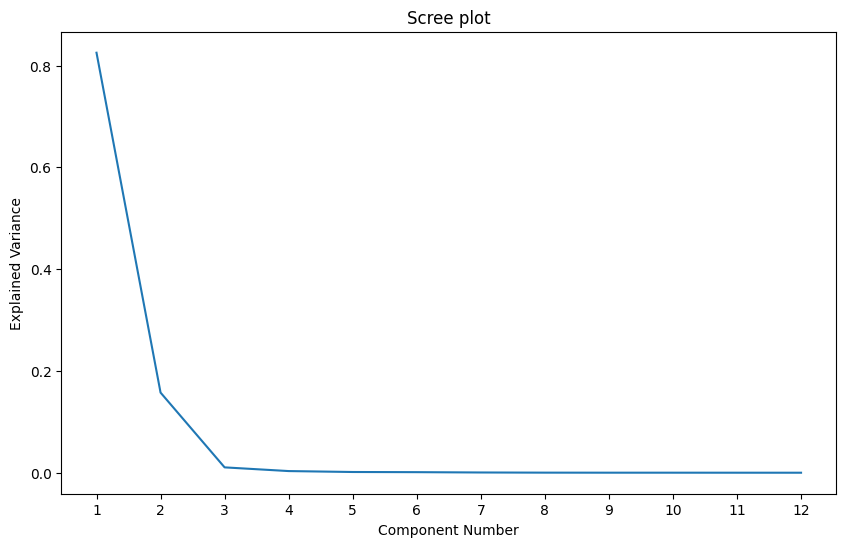

In [12]:
plt.rcParams['figure.figsize'] = (10, 6)
fig, ax = plt.subplots()

ind = numpy.arange(0, 12)
plt.plot(ind, pca.explained_variance_ratio_)
ax.set_xticks(ind)
ax.set_xticklabels(ind+1)
plt.title('Scree plot')
plt.xlabel('Component Number')
plt.ylabel('Explained Variance')
plt.show()

The first principal component alone explains 82.5% of the total variance in the dataset. The second component explains an additional 15.7%. Altogether, the first two components account for about 98.3% of the total variance.

The subsequent components each explain only a very small share of the variance (less than 2% from the third component onward, and then almost negligible), indicating that they do not bring any additional structured information.

The scree plot confirms this analysis: there is a sharp drop in explained variance between the first and second components, followed by a rapid flattening of the curve starting from the third component. The very clear “elbow” after the second component fully justifies representing the dataset using only the first two axes.

**Question 4**: Give two capital cities that are representative of Axis 1 and located at opposite ends of the axis. Consider the contributions or the cos² values and identify two cities with coordinates of opposite signs (see the visualization!).

In [13]:
proj_comp = temp_pca

*Reminder*: The contribution of an individual to a component corresponds to that individual’s coordinate on this component squared, divided by the eigenvalue and the individual’s weight: $\frac{(c_k^i)^2}{n \lambda_k}$.  
It is possible to obtain this result very simply from the single variable `proj_comp`. How?

In [14]:
n = t_capital.shape[0]

contrib = (proj_comp ** 2) / (n * pca.explained_variance_)

In [15]:
contrib_pd = pd.DataFrame(
    {
        "City": t_capital.index,
        "Contribution à Axe_1": contrib[:, 0] * 100,
        "Contribution à Axe_2": contrib[:, 1] * 100
    }
)

contrib_pd

,City,Contribution à Axe_1,Contribution à Axe_2
0,Amsterdam,0.017045,3.839179
1,Athens,24.002597,2.195653
2,Berlin,0.040648,0.008498
3,Brussels,0.153609,2.784883
4,Budapest,1.132338,6.811658
5,Copenhagen,0.926012,0.435011
6,Dublin,0.118230,15.097050
7,Elsinki,6.901415,0.549176
8,Kiev,1.258831,9.203681
9,Krakow,0.687239,1.847064


We then compute the cosine of the angle between each individual and the principal components. When working in the target space defined by the new axes, these values are very easy to obtain. What do these values represent? What is the interest of the squared cosine when working with multiple dimensions?

In [16]:
cos2_proj = (proj_comp ** 2) / np.sum(proj_comp ** 2, axis=1, keepdims=True)

In [17]:
contrib_pd = contrib_pd.assign(
    Cos2_axe_1 = cos2_proj[:, 0],
    Cos2_axe_2 = cos2_proj[:, 1]
)

contrib_pd

,City,Contribution à Axe_1,Contribution à Axe_2,Cos2_axe_1,Cos2_axe_2
0,Amsterdam,0.017045,3.839179,0.021142,0.908600
1,Athens,24.002597,2.195653,0.975857,0.017033
2,Berlin,0.040648,0.008498,0.367250,0.014649
3,Brussels,0.153609,2.784883,0.217529,0.752488
4,Budapest,1.132338,6.811658,0.443489,0.509041
5,Copenhagen,0.926012,0.435011,0.822618,0.073735
6,Dublin,0.118230,15.097050,0.038983,0.949794
7,Elsinki,6.901415,0.549176,0.955069,0.014501
8,Kiev,1.258831,9.203681,0.413861,0.577353
9,Krakow,0.687239,1.847064,0.634056,0.325158


Axis 1 is mainly driven by individuals with high contributions and a high cos² on this axis, and that are located at opposite positions in terms of sign.

- Athens is a capital city that is highly representative of the positive side of Axis 1:
  - Very high contribution to Axis 1 (≈ 24%),
  - Cos² on Axis 1 close to 1 (≈ 0.98),
  - It is therefore very well represented on this axis and strongly contributes to its construction.
  - It corresponds to a generally warm climate.

- Reykjavik is a capital city that is highly representative of the negative side of Axis 1:
  - High contribution to Axis 1 (≈ 9.4%),
  - High cos² on Axis 1 (≈ 0.72),
  - It is well represented and plays an important role in defining the axis.
  - It corresponds to a cold climate.

These two capital cities, located at opposite extremes of Axis 1, are therefore particularly representative of this axis, which contrasts warm cities with cold cities.

**Question 5**: Do the same with the supplementary individuals (which play the role of validation data), i.e. the cities that are not capital cities.

Here, one must first project the supplementary individuals using the axes obtained from the active individuals, namely the capital cities.

In [18]:
t_cities = temperature.iloc[24:][months]

t_cities_norm = scaler.transform(t_cities)

proj_comp_c = pca.transform(t_cities_norm)
cos2_c = cos2_c = (proj_comp_c ** 2) / np.sum(proj_comp_c ** 2, axis=1, keepdims=True)

In [19]:
contrib_pd_c = pd.DataFrame(
    {
        "Individus supplémentaires": temperature.index[24:],
        "Cos2_axe_1": cos2_c[:, 0],
        "Cos2_axe_2": cos2_c[:, 1]
    }
)

contrib_pd_c

,Individus supplémentaires,Cos2_axe_1,Cos2_axe_2
0,Barcelona,0.994878,0.002812
1,Bordeaux,0.930580,0.053089
2,Edinburgh,0.243897,0.744760
3,Frankfurt,0.290860,0.089353
4,Geneva,0.305935,0.163169
5,Genoa,0.993660,0.000113
6,Milan,0.777253,0.205566
7,Palermo,0.969174,0.000352
8,Seville,0.996811,0.001753
9,St. Petersburg,0.826020,0.133069


The supplementary individuals are generally well represented in the plane defined by the first two components. Most cities exhibit a very high cos² on Axis 1, indicating that their position is mainly explained by the overall thermal gradient (for example Barcelona, Genoa, Palermo, or Seville).

Some cities, such as Edinburgh, show a higher cos² on Axis 2, reflecting stronger seasonal variability and the influence of an oceanic climate.

These results show that non-capital cities are positioned consistently relative to capital cities in the factorial space, which validates the climatic typology obtained through the PCA.

**Question 6**: Which months contribute the most to the inertia on Axis 1? On Axis 2?

In [20]:
contrib_v = (corvar ** 2) / pca.explained_variance_

corvar_pd = corvar_pd.assign(Contribution_axe_1 = contrib_v[:,0]*100,
                             Contribution_axe_2 = contrib_v[:,1]*100)
corvar_pd

,Variable,COR_1,COR_2,Contribution_axe_1,Contribution_axe_2
0,January,0.840325,-0.534646,6.833121,14.496523
1,February,0.883750,-0.455658,7.557585,10.529532
2,March,0.943440,-0.292897,8.612980,4.350727
3,April,0.973972,0.098509,9.179464,0.492136
4,May,0.868123,0.460500,7.292687,10.754516
5,June,0.826744,0.554975,6.614036,15.619885
6,July,0.839618,0.516330,6.821631,13.520279
7,August,0.906389,0.408385,7.949755,8.458066
8,September,0.984940,0.156516,9.387372,1.242362
9,October,0.990930,-0.090117,9.501897,0.411857


On Axis 1, the months that contribute the most to inertia are April, September, and October, with contributions close to or above 9%. More generally, all spring, summer, and early autumn months show high and relatively homogeneous contributions. This confirms that Axis 1 is driven by an overall thermal level effect, linked to average temperatures throughout the year.

On Axis 2, the largest contributions mainly come from summer and winter months, in particular June and July, as well as December and January. This axis therefore clearly contrasts summer and winter temperatures and reflects the seasonal variability of climates, characteristic of the opposition between continental and oceanic climates.

**Question 7**: Compute the correlations and cos² for the additional quantitative variables. To which principal component can each supplementary variable be primarily associated?

Note that these projections are not directly available, since we are dealing with supplementary variables. They must therefore be computed manually. One can reuse the formula from Question 2.

In [21]:
t_suppl = temperature.loc[t_capital.index, ["Annual", "Amplitude", "Latitude", "Longitude"]]

scaler_suppl = StandardScaler()
t_suppl_norm = scaler_suppl.fit_transform(t_suppl)

n = t_capital.shape[0]
sqrt_eigval = np.sqrt((n - 1) / n * pca.explained_variance_)   

corr_suppl = (t_suppl_norm.T @ temp_pca) / (n * sqrt_eigval)

corvar_suppl_pd = pd.DataFrame({
    "id": t_suppl.columns,
    "Contribution_axe_1": corr_suppl[:, 0],
    "Contribution_axe_2": corr_suppl[:, 1]
})

corvar_suppl_pd

,id,Contribution_axe_1,Contribution_axe_2
0,Annual,0.997419,-0.070223
1,Amplitude,-0.315532,0.944051
2,Latitude,-0.908238,-0.221633
3,Longitude,-0.362891,0.655600


In [22]:
cos2_suppl = corr_suppl ** 2

corvar_suppl_pd = corvar_suppl_pd.assign(
    Cos2_axe_1 = cos2_suppl[:, 0],
    Cos2_axe_2 = cos2_suppl[:, 1]
)

corvar_suppl_pd

,id,Contribution_axe_1,Contribution_axe_2,Cos2_axe_1,Cos2_axe_2
0,Annual,0.997419,-0.070223,0.994845,0.004931
1,Amplitude,-0.315532,0.944051,0.099561,0.891232
2,Latitude,-0.908238,-0.221633,0.824896,0.049121
3,Longitude,-0.362891,0.655600,0.131690,0.429812


Let us try to visualize all of this in the correlation circle:

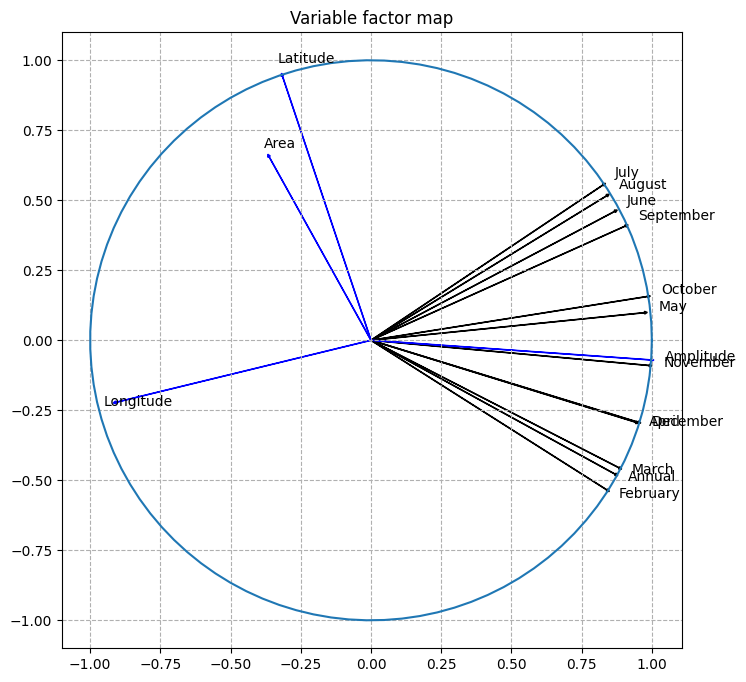

In [23]:
# Plot a variable factor map for the first two dimensions.
(fig, ax) = plt.subplots(figsize=(8, 8))
for i in range(0, corvar.shape[0]):
    ax.arrow(0,
             0,  # Start the arrow at the origin
             corvar[i, 0],  #0 for PC1
             corvar[i, 1],  #1 for PC2
             head_width=0.01,
             head_length=0.01)

    plt.text(corvar[i, 0]*1.05,
             corvar[i, 1]*1.05,
             temperature.columns.values[i+1])
    
for i in range(0, corr_suppl.shape[0]):
    ax.arrow(0,
             0,  # Start the arrow at the origin
             corr_suppl[i, 0],  #0 for PC1
             corr_suppl[i, 1],  #1 for PC2
             head_width=0.01,
             head_length=0.01,
             color='blue')

    plt.text(corr_suppl[i, 0]*1.05,
             corr_suppl[i, 1]*1.05,
             temperature.columns.values[i+13])
    
an = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(an), np.sin(an))  
plt.grid(True, linestyle="--")
plt.axis('equal') 
ax.set_title('Variable factor map')
plt.show()  

The correlations and cos² values of the additional quantitative variables make it possible to associate each of them with the principal components.

- Annual is very strongly correlated with Component 1 (correlation ≈ 0.997) and has a very high cos² on this axis (≈ 0.995). It is therefore almost entirely explained by Axis 1, which confirms that this axis corresponds to the average thermal level.

- Latitude is also strongly correlated with Component 1 (correlation ≈ −0.91, cos² ≈ 0.82). The negative sign simply reflects the orientation of the axis, but shows that latitude is closely linked to the North–South thermal gradient carried by Component 1.

- Amplitude is mainly correlated with Component 2 (correlation ≈ 0.94, cos² ≈ 0.89). It is therefore primarily associated with Axis 2, which captures seasonal variability and the continentality of climates.

- Longitude shows more moderate correlations, but is more strongly related to Component 2 (cos² ≈ 0.43) than to Component 1. Its role is secondary and less structuring than that of the other variables.

The supplementary variables confirm the interpretation of the axes: Component 1 is associated with the average thermal level and latitude, while Component 2 is associated with seasonal amplitude.

**Question 8:** Regarding the supplementary qualitative variables: each category is represented by the barycenter of the individuals that belong to it. To which principal component is the “East” category most strongly correlated? What is the sign of this correlation?

In [24]:
t_cat = temperature.iloc[0:23].filter(items = ["January","February","March","April","May","June","July","August","September","October","November","December","Area"]).groupby("Area", as_index=False).mean()
t_cat

,Area,January,February,March,April,May,June,July,August,September,October,November,December
0,East,-4.271429,-2.800000,1.585714,8.114286,14.071429,17.528571,19.257143,18.371429,13.971429,8.342857,2.385714,-1.985714
1,North,-0.871429,-0.657143,1.271429,5.114286,9.942857,13.800000,15.914286,14.942857,11.485714,7.228571,3.014286,0.642857
2,South,6.060000,7.320000,9.860000,13.020000,16.880000,20.680000,23.380000,23.240000,20.020000,15.500000,10.760000,7.320000
3,West,2.425000,2.400000,6.025000,8.750000,13.200000,15.725000,18.050000,17.900000,15.000000,11.250000,6.300000,3.800000


In [25]:
t_cat_months = t_cat[months]

t_cat_norm = scaler.transform(t_cat_months)

proj_comp_cat = pca.transform(t_cat_norm)

In [26]:
# Cos² for categories 
cos2_cat = (proj_comp_cat ** 2) / np.sum(proj_comp_cat ** 2, axis=1, keepdims=True)

cos2_cat = pd.DataFrame(
    {
        "Id": t_cat.index,   
        "Cos2 avec l'axe 1": cos2_cat[:, 0],
        "Coordonnée dans l'axe 1": proj_comp_cat[:, 0],
        "Cos2 avec l'axe 2": cos2_cat[:, 1],
        "Coordonnée dans l'axe 2": proj_comp_cat[:, 1],
    }
)

cos2_cat

,Id,Cos2 avec l'axe 1,Coordonnée dans l'axe 1,Cos2 avec l'axe 2,Coordonnée dans l'axe 2
0,0,0.375408,-1.142990,0.604049,1.449861
1,1,0.862148,-2.515088,0.126105,-0.961898
2,2,0.997017,4.621239,0.001912,0.202392
3,3,0.234936,0.481467,0.687425,-0.823578


The East category is mainly associated with Component 2.

Indeed, its cos² with Axis 2 is higher than its cos² with Axis 1 (≈ 0.60 versus ≈ 0.38), indicating that Component 2 explains the position of this category better than Component 1.

The coordinate on Axis 2 is positive, meaning that the East category lies on the positive side of Component 2. This position is consistent with the climatic interpretation of Axis 2, which is associated with seasonal variability and continentality of climates.

Thus, the East category is primarily correlated with Axis 2, with a positive correlation.

**Question 9:** Based solely on the first two PCA components, can we infer the sign of the correlation between “amplitude” and “January”?

In [27]:
corvar_pd[corvar_pd["Variable"] == "January"]

corvar_suppl_pd[corvar_suppl_pd["id"] == "Amplitude"]

,id,Contribution_axe_1,Contribution_axe_2,Cos2_axe_1,Cos2_axe_2
1,Amplitude,-0.315532,0.944051,0.099561,0.891232


In [28]:
temperature.loc[t_capital.index, ["January", "Amplitude"]].corr()

,January,Amplitude
January,1.000000,-0.771064
Amplitude,-0.771064,1.000000


Based solely on the first two PCA components, we can anticipate that the correlation between Amplitude and January is negative. Indeed, the Amplitude variable is strongly and positively correlated with Component 2 (correlation ≈ 0.94, cos² ≈ 0.89), while the month of January is negatively correlated with this same component. Two variables projected in opposite directions along a principal axis are therefore negatively correlated.

This geometric interpretation is confirmed by the direct computation of the empirical correlation between the two variables, which is approximately −0.77. Thus, a large seasonal amplitude is associated with lower January temperatures, which is climatically consistent.

**Conclusion:**  dressez une typologie sommaire des températures en Europe.

The principal component analysis carried out on monthly temperatures makes it possible to identify a clear climatic typology of European cities. The first two components explain nearly 98% of the total variance and are sufficient to summarize the information.

The first component reflects an overall thermal gradient, contrasting cities in Southern Europe, characterized by high temperatures throughout the year, with cities in Northern Europe, where average temperatures are lower. This axis is strongly linked to latitude and to the average thermal level.

The second component captures the seasonal variability of temperatures. It distinguishes continental climates, marked by a large amplitude between winter and summer (mainly in Eastern Europe), from oceanic climates, where temperatures are more moderate and more stable over the year (mainly in Western Europe).

Thus, Europe can be broadly structured into major climatic groups:

- a warm southern climate,
- a cold northern climate,
- an oceanic climate with low seasonal amplitude,
- and a continental climate with high seasonal amplitude.

This typology is consistent with European geography and is validated by the analysis of supplementary variables and supplementary individuals.

### Exersice 2

We use the Olympic Games (JO) data. Rows correspond to Olympic disciplines, and columns to countries. Each cell contains the number of medals (gold/silver/bronze) won by a country between 1992 and 2008 (5 Olympic Games, i.e. 15 medals per discipline).

This is indeed a (sparse) contingency table obtained from original binary data where each row corresponds to a single medal, with two “1”s per row (the country concerned and the discipline), all remaining cells being 0. There are 24 disciplines.

To load the contingency table and display the data description:

In [53]:
JO = pd.read_csv("JO.csv", sep=";")

sports = JO.iloc[:, 0].to_numpy()

JO_num = JO.iloc[:, 1:].apply(pd.to_numeric, errors="coerce").fillna(0).astype(float)
countries = JO_num.columns.to_numpy()

print(JO.head(3))
print("JO shape:", JO.shape)
print("JO_num shape:", JO_num.shape)

           alg  aus  bah  bar  bdi  blr  bra  brn  can  ...  slo  sud  swe  \
0  10000m    0    0    0    0    0    0    0    0    0  ...    0    0    0   
1    100m    0    0    0    1    0    0    0    0    1  ...    0    0    0   
2   110mH    0    0    0    0    0    0    0    0    1  ...    0    0    0   

   tch  tri  tur  uga  ukr  usa  zam  
0    0    0    0    0    0    0    0  
1    0    3    0    0    0    5    0  
2    0    0    0    0    0    9    0  

[3 rows x 59 columns]
JO shape: (24, 59)
JO_num shape: (24, 58)


In [54]:
medals_per_sport = JO_num.sum(axis=1)
print("Toutes les disciplines ont 15 médailles ? ->", (medals_per_sport == 15).all())
print("Disciplines != 15:", JO.loc[medals_per_sport != 15, JO.columns[0]].to_list())

medals_per_country = JO_num.sum(axis=0).sort_values(ascending=False)
medals_per_country.head(15)

Toutes les disciplines ont 15 médailles ? -> True
Disciplines != 15: []


usa    82.0
ken    35.0
rus    19.0
eth    15.0
gbr    15.0
cub    14.0
mar    10.0
ger    10.0
jam     9.0
esp     8.0
pol     8.0
ita     7.0
eun     7.0
rsa     6.0
aus     6.0
dtype: float64

In [84]:
# The chi-square test strongly rejects independence, but it is not significant
# because the condition n_{ij} > 5 for all (i, j) is not satisfied.
from scipy.stats import chi2_contingency
chi2_contingency(JO.iloc[:,1:])

Chi2ContingencyResult(statistic=np.float64(2122.231456690507), pvalue=np.float64(2.3209814011971706e-41), dof=1311, expected_freq=array([[0.16666667, 0.25      , 0.125     , ..., 0.20833333, 3.41666667,
        0.04166667],
       [0.16666667, 0.25      , 0.125     , ..., 0.20833333, 3.41666667,
        0.04166667],
       [0.16666667, 0.25      , 0.125     , ..., 0.20833333, 3.41666667,
        0.04166667],
       ...,
       [0.16666667, 0.25      , 0.125     , ..., 0.20833333, 3.41666667,
        0.04166667],
       [0.16666667, 0.25      , 0.125     , ..., 0.20833333, 3.41666667,
        0.04166667],
       [0.16666667, 0.25      , 0.125     , ..., 0.20833333, 3.41666667,
        0.04166667]], shape=(24, 58)))

**Question 1:** Inspect the eigenvalues of the CA. How many dimensions should be retained to explain 50% of the variance?

In [56]:
mca_JO = mca.MCA(JO_num, benzecri=False)

eigval = mca_JO.L
eig_ratio = eigval / eigval.sum()
eig_cum = np.cumsum(eig_ratio)

eig_df = pd.DataFrame({
    "Dimension": [f"Dim{i+1}" for i in range(len(eigval))],
    "Valeur propre": eigval,
    "% Variance expliquée": eig_ratio * 100,
    "% Variance cumulée": eig_cum * 100
})

eig_df

,Dimension,Valeur propre,% Variance expliquée,% Variance cumulée
0,Dim1,0.816698,13.853867,13.853867
1,Dim2,0.620710,10.529273,24.383140
2,Dim3,0.544244,9.232162,33.615301
3,Dim4,0.481178,8.162354,41.777656
4,Dim5,0.396222,6.721228,48.498884
5,Dim6,0.363955,6.173864,54.672748
6,Dim7,0.327389,5.553585,60.226333
7,Dim8,0.315429,5.350712,65.577044
8,Dim9,0.268808,4.559865,70.136909
9,Dim10,0.244979,4.155639,74.292549


In [57]:
# amount of dimensions to reach 50% cumulative variance
k50 = int(np.argmax(eig_cum >= 0.50) + 1)
k50

6

We use ```mca``` package. The attribute ```.L``` of object ```MCA``` give eigenvalues

The inspection of the eigenvalues from the correspondence analysis shows that the variance is spread over a relatively large number of dimensions. The cumulative explained variance exceeds 50% starting from the 6th dimension (about 54.6%).

It is therefore necessary to retain 6 dimensions to explain at least half of the total variance. This dispersion of variance is characteristic of correspondence analyses applied to sparse contingency tables, such as the disciplines × countries table considered here.

**Question 2:** Check that inertia total =  $\frac{1}{n}$ * the χ2 statistic.

```.inertia``` attribute gives the total intertia

In [58]:
chi2_stat, pval, dof, expected = chi2_contingency(JO_num.values)

n = JO_num.values.sum()
inertia_ac = mca_JO.inertia

print("Inertie AC :", inertia_ac)
print("Chi2 / n   :", chi2_stat / n)
print("Diff       :", inertia_ac - chi2_stat / n)

Inertie AC : 5.895087379695811
Chi2 / n   : 5.895087379695853
Diff       : -4.1744385725905886e-14


The total inertia provided by the correspondence analysis is equal to the chi-square (χ²) statistic divided by the total number of observations. Numerically, we verify that the inertia given by the ```.inertia_``` attribute of the MCA object matches χ² / n. This equality confirms the theoretical link between correspondence analysis and the chi-square test of independence.

**Question 3:** Check that the barycenter of the projections of the row profiles onto the first two axes is the zero vector, when using the marginal frequencies as weights.
Let us first verify one thing: is the barycenter of the row profiles (i.e. normalized rows) indeed equal to the marginal column profile?

In [59]:
n = JO_num.values.sum()

rowW = JO_num.sum(axis=1).to_numpy() / n  
colW = JO_num.sum(axis=0).to_numpy() / n   

rowprof = JO_num.div(JO_num.sum(axis=1), axis=0).to_numpy()

print(np.dot(rowW, rowprof) - colW)  

[-1.73472348e-18 -3.46944695e-18 -1.73472348e-18 -4.33680869e-19
 -4.33680869e-19 -3.46944695e-18 -1.73472348e-18 -4.33680869e-19
 -1.73472348e-18 -4.33680869e-19  0.00000000e+00 -3.46944695e-18
 -1.73472348e-18 -4.33680869e-19 -8.67361738e-19 -4.33680869e-19
 -3.46944695e-18 -1.73472348e-18  0.00000000e+00  0.00000000e+00
 -1.73472348e-18 -1.73472348e-18  0.00000000e+00  0.00000000e+00
 -4.33680869e-19 -1.73472348e-18 -3.46944695e-18 -3.46944695e-18
 -1.73472348e-18 -4.33680869e-19 -1.38777878e-17 -8.67361738e-19
 -4.33680869e-19 -1.73472348e-18 -1.73472348e-18  0.00000000e+00
 -1.73472348e-18 -1.73472348e-18 -1.73472348e-18  0.00000000e+00
 -4.33680869e-19 -4.33680869e-19 -3.46944695e-18 -1.73472348e-18
 -4.33680869e-19 -4.33680869e-19 -3.46944695e-18  6.93889390e-18
 -4.33680869e-19 -4.33680869e-19 -1.73472348e-18 -8.67361738e-19
  0.00000000e+00 -4.33680869e-19 -4.33680869e-19  0.00000000e+00
  0.00000000e+00 -4.33680869e-19]


In [60]:
row_proj = mca_JO.fs_r()
col_proj = mca_JO.fs_c()

print("Barycentre lignes (axes 1-2):", np.dot(rowW, row_proj[:, :2]))
print("Barycentre colonnes (axes 1-2):", np.dot(colW, col_proj[:, :2]))

Barycentre lignes (axes 1-2): [-5.55111512e-17  1.26634814e-16]
Barycentre colonnes (axes 1-2): [-8.21923884e-17 -2.02104546e-16]


First, we verify that the barycenter of the row profiles (normalized rows), weighted by the row marginal frequencies, is equal to the column marginal profile. Numerically, the observed difference is on the order of 10⁻¹⁸, which corresponds to numerical error and confirms the theoretical equality.

Next, we compute the barycenter of the projections of the row profiles onto the first two factorial axes using the marginal frequencies as weights. The result is a vector very close to the zero vector (coordinates on the order of 10⁻¹⁶). The same property is verified for the column profiles.

These results confirm that, in correspondence analysis, the factorial axes are centered: the weighted barycenter of the projections of both row and column profiles lies at the origin when marginal weights are used.

**Question 4:** Check that the weighted variance of the row coordinates on the first axis is equal to the first eigenvalue.

In [61]:
lambda1 = mca_JO.L[0]
var_axis1 = np.sum(rowW * row_proj[:, 0]**2)

print("Var pondérée axe1 :", var_axis1)
print("Valeur propre λ1  :", lambda1)
print("Diff              :", var_axis1 - lambda1)

Var pondérée axe1 : 0.8166975526447365
Valeur propre λ1  : 0.8166975526447371
Diff              : -5.551115123125783e-16


The weighted variance of the coordinates of the row profiles on the first axis, computed using the marginal frequencies as weights, is numerically equal to the first eigenvalue of the correspondence analysis. This equality confirms that the eigenvalue associated with a factorial axis indeed corresponds to the variance explained by that axis in the cloud of row profiles.

**Question 5:** Check that the correlation between the vectors of coordinates of the row profiles projected onto Axis 1 and Axis 2 is zero. Provide a theoretical justification for this result.

In [62]:
cov12 = np.sum(rowW * row_proj[:, 0] * row_proj[:, 1])
cov12

np.float64(5.551115123125783e-17)

The computation of the weighted inner product between the vectors of coordinates of the row profiles projected onto Axis 1 and Axis 2 yields a value on the order of 10⁻¹⁷, which is numerically equal to zero. The correlation between these two vectors is therefore zero.

From a theoretical standpoint, this result is expected: in correspondence analysis, the factorial axes are obtained as orthogonal eigenvectors of a symmetric operator (linked to the χ² statistic). This orthogonality implies that the coordinates projected onto two distinct axes are uncorrelated with respect to the metric weighted by the marginal frequencies.

**Question 6:** Compute the contributions of the row profiles to Axis 1 using the weights, the row coordinates, and the eigenvalues.

In [63]:
lambda1 = mca_JO.L[0]
contrib_row_axis1 = (rowW * row_proj[:, 0]**2) / lambda1

print("Somme des contributions :", contrib_row_axis1.sum())

contr_rows = (
    pd.DataFrame({"Discipline": sports, "Contribution Axe 1": contrib_row_axis1})
    .sort_values("Contribution Axe 1", ascending=False)
    .reset_index(drop=True)
)

contr_rows.head(15)

Somme des contributions : 0.9999999999999993


,Discipline,Contribution Axe 1
0,10000m,0.238499
1,5000m,0.177858
2,3000mSteeple,0.132301
3,1500m,0.110162
4,Marathon,0.066694
5,800m,0.028772
6,200m,0.026121
7,100m,0.023474
8,4x400m,0.022191
9,Triple saut,0.018758


The contributions of the row profiles to Axis 1 were computed using the theoretical formula from **Correspondence Analysis**:

$$
\text{contr}_{i,1} = \frac{w_i \, c_{i1}^2}{\lambda_1}
$$

where:
- $w_i$ is the weight (marginal frequency) of row $i$,
- $c_{i1}$ is the coordinate of row $i$ on Axis 1,
- $\lambda_1$ is the first eigenvalue.

The sum of the contributions satisfies:
$$
\sum_i \text{contr}_{i,1} \approx 1
$$
(up to numerical error), which validates the computation.

Axis 1 is mainly structured by a limited number of disciplines whose contributions are clearly above the average. These disciplines are those that deviate the most from the average profile and therefore play a central role in the construction of the first factorial dimension. Conversely, most disciplines have low contributions and only weakly participate in the inertia of Axis 1.

**Interpretation:** Axis 1 is dominated by a few highly discriminative disciplines, which is a typical behavior in Correspondence Analysis.

**Question 7:** Interpretation of the results:
- How can the axes of the PCA of the rows be interpreted in light of the row profile plot?
- We aim to build country profiles in terms of disciplinary strengths. Add the countries to the plot.
- Compute the contributions of the countries to Axis 1 using their weights, the column coordinates, and the first eigenvalue (see Question 6).
- Which are the 5 countries that contribute the most to the inertia on Axis 1? On which side are the United States located relative to the “endurance” direction?

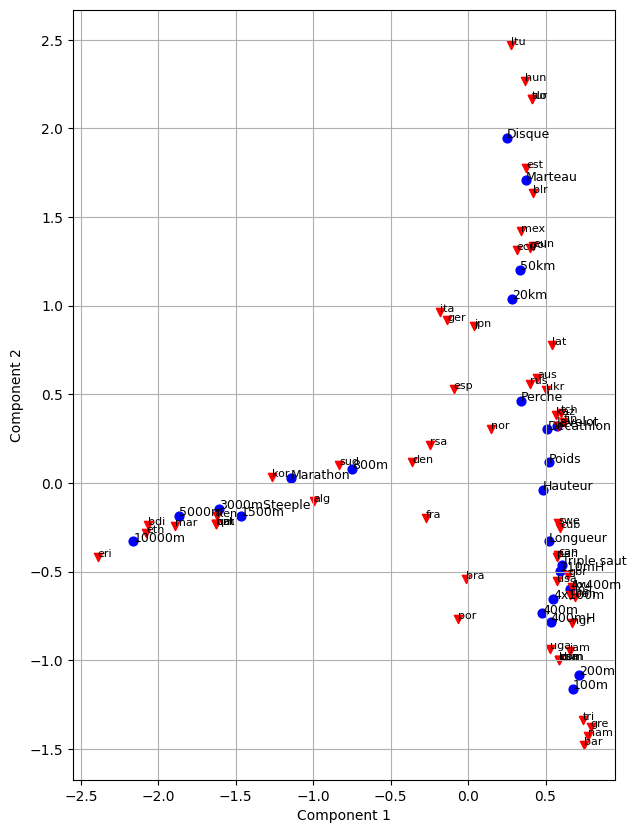

In [ ]:
plt.rcParams['figure.figsize'] = (7, 10)
fig, ax = plt.subplots()

ax.scatter(row_proj[:, 0], row_proj[:, 1], c="b", s=40)
for k in range(row_proj.shape[0]):
    ax.annotate(sports[k], (row_proj[k, 0], row_proj[k, 1]), fontsize=9)

ax.scatter(col_proj[:, 0], col_proj[:, 1], c="r", marker="v", s=35)
for k in range(col_proj.shape[0]): 
    ax.annotate(countries[k], (col_proj[k, 0], col_proj[k, 1]), fontsize=8)

ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")
ax.grid(True)
plt.show()

In [68]:
lambda1 = mca_JO.L[0]
contrib_col_axis1 = (colW * col_proj[:, 0]**2) / lambda1

contr_country = (
    pd.DataFrame({"Country": countries, "Contribution Axe 1": contrib_col_axis1})
    .sort_values("Contribution Axe 1", ascending=False)
    .reset_index(drop=True)
)

contr_country.head(10)

,Country,Contribution Axe 1
0,ken,0.313875
1,eth,0.220721
2,mar,0.121601
3,usa,0.091490
4,gbr,0.021388
5,eri,0.019469
6,cub,0.016828
7,bdi,0.014519
8,alg,0.013520
9,jam,0.013127


- Axis 1 clearly contrasts endurance disciplines (10,000 m, 5,000 m, 1,500 m, 3,000 m steeple, marathon), located on the negative side, with more *explosive/technical disciplines (jumps, sprints/relays, throws…), mostly on the positive side. Dimension 1 can therefore be read as an endurance ↔ power/technicality axis.

- Axis 2 mainly separates certain blocks of disciplines: at the top we find throws / race walking (discus, hammer, 20–50 km…), while at the bottom appear more pure speed disciplines (100 m/200 m, relays) and some jumps. Dimension 2 resembles a contrast throws/walking ↔ sprint/speed (a “type of effort” interpretation).

*Country profiles (adding countries to the plot)* :

A country located close to a group of disciplines is over-represented (relative to the average) in those disciplines.
For example, a country positioned toward the “endurance” side is typically strong in middle- and long-distance events.

Top 5 countries contributing the most to inertia on Axis 1
According to the contribution table (Axis 1), the top five are: KEN, ETH, MAR, USA, GBR.
They structure the axis because they deviate the most from the average profile along Dimension 1.

Position of the USA relative to the “endurance” direction
The “endurance” direction lies on the negative side of Axis 1 (where 5,000 m, 10,000 m, marathon, etc. are located).
The United States are positioned rather on the opposite side (positive Axis 1), i.e. away from endurance, suggesting a profile relatively more oriented toward non-endurance disciplines (sprints/technical events) than toward long-distance running.

### Exersice 3

We load the banque.csv dataset: these data come from a survey of 810 bank customers and describe the clients according to several characteristics.  
Here, we retain the variables ```age, sexe, interdit, credhab, credcon``` (4,5,6,12,13).

In [69]:
banque = pd.read_csv("banque.csv", sep=",")
banque = banque[["age", "sexe","interdit","credhab","credcon"]]
banque.head()

,age,sexe,interdit,credhab,credcon
0,ai75,hom,non,non,nul
1,ai35,hom,non,non,nul
2,ai75,hom,non,non,nul
3,ai45,fem,oui,non,nul
4,ai75,hom,non,non,nul


In [ ]:
dij=pd.DataFrame(pd.get_dummies(banque))
dij.head()

,age_ai25,age_ai35,age_ai45,age_ai55,age_ai75,sexe_fem,sexe_hom,interdit_non,interdit_oui,credhab_non,credhab_oui,credcon_fai,credcon_for,credcon_nul
0,False,False,False,False,True,False,True,True,False,True,False,False,False,True
1,False,True,False,False,False,False,True,True,False,True,False,False,False,True
2,False,False,False,False,True,False,True,True,False,True,False,False,False,True
3,False,False,True,False,False,True,False,False,True,True,False,False,False,True
4,False,False,False,False,True,False,True,True,False,True,False,False,False,True


**Question 1:** Without any computation, give the total sum of the disjunctive table and the sum of each row. Study the frequencies of each modality and identify any potentially rare modalities.

- In a complete disjunctive table, each individual activates exactly one modality per variable.
- Here, we have 810 clients and 5 variables (age, gender, banned, housing_credit, consumer_credit).
- Therefore, each row contains 5 ones (one per variable) → row sum = 5.
- The total sum of the disjunctive table is thus 810 × 5 = 4050.

In [ ]:
# Double check
print("Somme totale dij :", dij.to_numpy().sum())
print("Sommes par ligne (min, max):", dij.sum(axis=1).min(), dij.sum(axis=1).max())

Somme totale dij : 4050
Sommes par ligne (min, max): 5 5


In [ ]:
mod_counts = dij.sum(axis=0).sort_values()
mod_counts

credcon_for      57
interdit_oui     58
credcon_fai      68
age_ai25         90
credhab_oui      92
age_ai35        156
age_ai55        174
age_ai75        178
age_ai45        212
sexe_fem        252
sexe_hom        558
credcon_nul     685
credhab_non     718
interdit_non    752
dtype: int64

In [ ]:
rare = mod_counts[mod_counts < 10]
rare

Series([], dtype: int64)

**Question 2:** We perform a Multiple Correspondence Analysis (MCA):
- Compute the total inertia and report the relative inertia of each axis.
- Recover the total inertia from the χ² statistic of the disjunctive table.
- Which are the three categories that contribute the most to Axis 1?
- Same question for Axis 2.

In [ ]:
mca_banque = mca.MCA(dij, benzecri=False)

# eigenvalues
eigval = mca_banque.L
eig_ratio = eigval / eigval.sum()
eig_cum = np.cumsum(eig_ratio)

eig_df = pd.DataFrame({
    "Dimension": [f"Dim{i+1}" for i in range(len(eigval))],
    "Valeur propre": eigval,
    "% Inertie": eig_ratio * 100,
    "% Inertie cumulée": eig_cum * 100
})
eig_df.head(15)

,Dimension,Valeur propre,% Inertie,% Inertie cumulée
0,Dim1,0.278490,15.471651,15.471651
1,Dim2,0.230506,12.805884,28.277535
2,Dim3,0.216993,12.055172,40.332707
3,Dim4,0.203149,11.286062,51.618769
4,Dim5,0.193799,10.766601,62.385370
5,Dim6,0.181638,10.090999,72.476370
6,Dim7,0.176523,9.806860,82.283229
7,Dim8,0.162759,9.042173,91.325403
8,Dim9,0.156143,8.674597,100.000000


In [ ]:
inertia_total = mca_banque.inertia
inertia_total

np.float64(1.7999999999999723)

In [78]:
chi2_stat, pval, dof, expected = chi2_contingency(dij.values)
n = dij.values.sum()

print("Inertie MCA :", mca_banque.inertia)
print("Chi2 / n    :", chi2_stat / n)
print("Diff        :", mca_banque.inertia - chi2_stat / n)

Inertie MCA : 1.7999999999999723
Chi2 / n    : 1.8
Diff        : -2.7755575615628914e-14


In [ ]:
col_proj = mca_banque.fs_c()  
colW = dij.sum(axis=0).to_numpy() / dij.to_numpy().sum() 

lambda1 = mca_banque.L[0]
lambda2 = mca_banque.L[1]

contrib_axis1 = (colW * col_proj[:, 0]**2) / lambda1
contrib_axis2 = (colW * col_proj[:, 1]**2) / lambda2

contr_df = pd.DataFrame({
    "Category": dij.columns,
    "Contr_Axe1": contrib_axis1,
    "Contr_Axe2": contrib_axis2
})

top3_axis1 = contr_df.sort_values("Contr_Axe1", ascending=False).head(3)
top3_axis2 = contr_df.sort_values("Contr_Axe2", ascending=False).head(3)

top3_axis1, top3_axis2

(       Category  Contr_Axe1  Contr_Axe2
 10  credhab_oui    0.242188    0.000178
 5      sexe_fem    0.175220    0.000984
 0      age_ai25    0.163090    0.002036,
        Category  Contr_Axe1  Contr_Axe2
 8  interdit_oui    0.013725    0.295780
 1      age_ai35    0.000265    0.235731
 4      age_ai75    0.020224    0.201987)

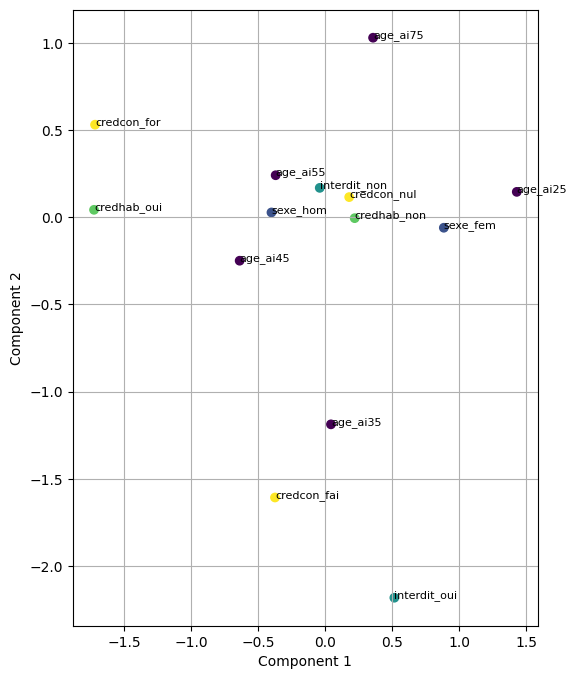

In [ ]:
plt.rcParams['figure.figsize'] = (6, 8)
fig, ax = plt.subplots()

colors = np.repeat(np.arange(1, 1+len(banque.columns)), [len([c for c in dij.columns if c.startswith(v + "_")]) for v in banque.columns])

ax.scatter(col_proj[:, 0], col_proj[:, 1], c=colors)

for k in range(dij.shape[1]):
    ax.annotate(dij.columns.to_numpy()[k], (col_proj[k, 0], col_proj[k, 1]), fontsize=8)

ax.set_xlabel("Component 1")
ax.set_ylabel("Component 2")
ax.grid(True)
plt.show()

**Conclusion:** Build a typology of the clients, that is, interpret the axes using the category map and the variable representations.

The multiple correspondence analysis highlights two main axes that clearly structure the profiles of bank customers.

**Axis 1 (Dimension 1)**
The first axis is mainly driven by the modalities credhab_yes, gender_female, and age_under25. It therefore contrasts:
- young, predominantly female clients with a housing loan (positive side),
- with profiles less involved in home borrowing, associated with other age groups and the refusal of certain types of credit.

This axis can be interpreted as a structuring access-to-credit axis, strongly linked to the life cycle and financial stability.

**Axis 2 (Dimension 2)**
The second axis is dominated by banned_yes, age_35, and age_75, and reflects an opposition between:
- situations of financial vulnerability (banking bans, refusal of consumer credit),
- and more neutral or intermediate profiles.

It corresponds to a banking risk / vulnerability axis, strongly correlated with specific age groups.

The MCA thus makes it possible to identify: a group of young, active, and solvent clients, oriented toward housing credit, a group of more fragile clients, associated with banking bans and credit refusal, intermediate profiles mainly structured by age and type of credit. This typology is economically coherent and shows that age, gender, and the relationship to credit are the key dimensions differentiating clients in this dataset.